# 01 — Market Coverage

Parse all tickers in our trade data, categorize by series type, measure volume, and confirm GAME markets as the primary target.

In [2]:
import sys
sys.path.insert(0, '/Users/chriswang/Desktop/prediction-market-exploration/nba-edge')

import polars as pl
from nba_edge.data.s3_reader import discover_trade_dates, load_trades
from nba_edge.data.ticker_parser import parse_ticker, SERIES_PREFIXES

In [3]:
# Load all trade data from 4/21 onward
dates = discover_trade_dates(min_date='2026-04-21')
print(f'Dates: {dates}')
df = load_trades(dates)
print(f'Total trades: {len(df):,}')

Dates: ['2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-25', '2026-04-26', '2026-04-27', '2026-05-02', '2026-05-03']
Total trades: 3,022,380


In [4]:
# Parse every ticker
tickers = df['market_ticker'].unique().to_list()
parsed = [parse_ticker(t) for t in tickers]

print(f'Unique tickers: {len(tickers)}')
print(f'\nBy series type:')
from collections import Counter
series_counts = Counter(p.series for p in parsed)
for s, c in series_counts.most_common():
    print(f'  {s:10s}: {c} markets')

Unique tickers: 1741

By series type:
  PTS       : 1025 markets
  TOTAL     : 320 markets
  SPREAD    : 316 markets
  GAME      : 80 markets


In [5]:
# Add series column to trades
ticker_to_series = {p.raw: p.series for p in parsed}
df = df.with_columns(
    pl.col('market_ticker').replace(ticker_to_series).alias('series')
)

# Volume by series type
series_stats = df.group_by('series').agg(
    pl.count().alias('n_trades'),
    pl.col('size').sum().alias('total_contracts'),
    pl.col('market_ticker').n_unique().alias('n_markets'),
).sort('n_trades', descending=True)

print('Volume by market type:')
print(series_stats)

Volume by market type:
shape: (4, 4)
┌────────┬──────────┬─────────────────┬───────────┐
│ series ┆ n_trades ┆ total_contracts ┆ n_markets │
│ ---    ┆ ---      ┆ ---             ┆ ---       │
│ cat    ┆ u32      ┆ i32             ┆ u32       │
╞════════╪══════════╪═════════════════╪═══════════╡
│ GAME   ┆ 1890906  ┆ 643416740       ┆ 80        │
│ SPREAD ┆ 542971   ┆ 112927774       ┆ 316       │
│ TOTAL  ┆ 457271   ┆ 89920998        ┆ 320       │
│ PTS    ┆ 131232   ┆ 9246004         ┆ 1025      │
└────────┴──────────┴─────────────────┴───────────┘


/var/folders/56/rfjtkv155ys98269zlkf45pc0000gn/T/ipykernel_68063/3742267636.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('n_trades'),


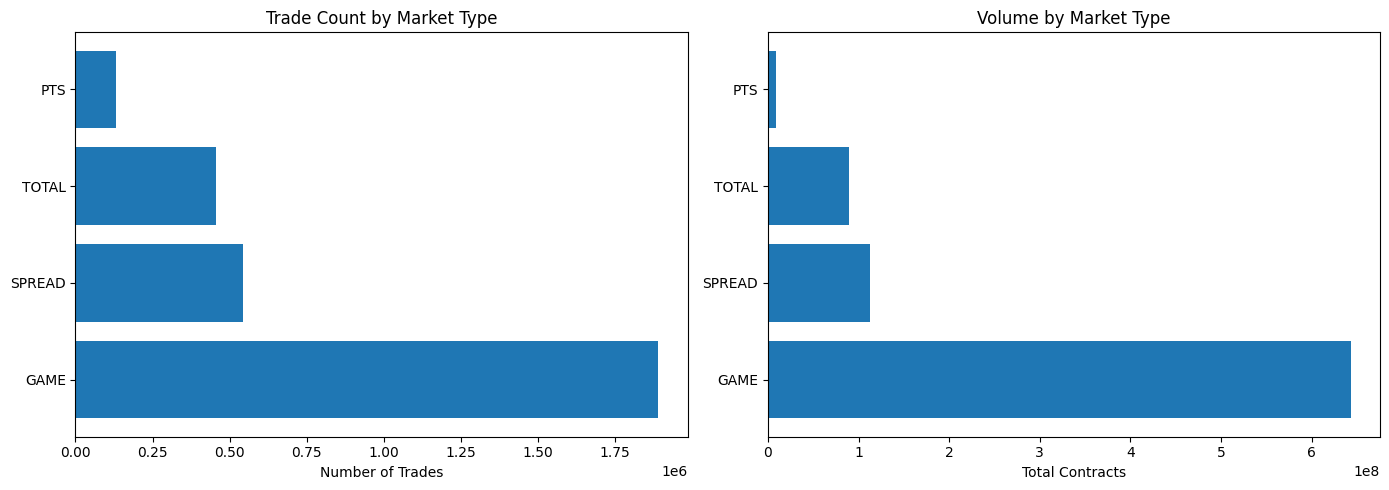

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trade count by series
axes[0].barh(series_stats['series'].to_list(), series_stats['n_trades'].to_list())
axes[0].set_xlabel('Number of Trades')
axes[0].set_title('Trade Count by Market Type')

# Contract volume by series
axes[1].barh(series_stats['series'].to_list(), series_stats['total_contracts'].to_list())
axes[1].set_xlabel('Total Contracts')
axes[1].set_title('Volume by Market Type')

plt.tight_layout()
plt.show()

In [7]:
# Focus on GAME markets — list all game winner tickers
game_tickers = [p for p in parsed if p.series == 'GAME']
print(f'GAME markets: {len(game_tickers)}')
print(f'\nAll GAME tickers:')
for p in sorted(game_tickers, key=lambda x: x.game_date or ''):
    trades_for = df.filter(pl.col('market_ticker') == p.raw)
    print(f'  {p.raw:45s} | date={p.game_date} | {p.away_team}@{p.home_team} | sel={p.selection} | trades={len(trades_for)}')

GAME markets: 80

All GAME tickers:
  KXNBAGAME-26APR20ATLNYK-ATL                   | date=2026-04-20 | ATL@NYK | sel=ATL | trades=34087
  KXNBAGAME-26APR20MINDEN-MIN                   | date=2026-04-20 | MIN@DEN | sel=MIN | trades=71576
  KXNBAGAME-26APR20ATLNYK-NYK                   | date=2026-04-20 | ATL@NYK | sel=NYK | trades=31706
  KXNBAGAME-26APR20MINDEN-DEN                   | date=2026-04-20 | MIN@DEN | sel=DEN | trades=38079
  KXNBAGAME-26APR20TORCLE-TOR                   | date=2026-04-20 | TOR@CLE | sel=TOR | trades=9726
  KXNBAGAME-26APR20TORCLE-CLE                   | date=2026-04-20 | TOR@CLE | sel=CLE | trades=4672
  KXNBAGAME-26APR21PHIBOS-PHI                   | date=2026-04-21 | PHI@BOS | sel=PHI | trades=54047
  KXNBAGAME-26APR21PHIBOS-BOS                   | date=2026-04-21 | PHI@BOS | sel=BOS | trades=30334
  KXNBAGAME-26APR21HOULAL-LAL                   | date=2026-04-21 | HOU@LAL | sel=LAL | trades=78799
  KXNBAGAME-26APR21PORSAS-POR                   | date=20

In [8]:
# For each game, there should be 2 GAME tickers (one per team)
# Group by game_date + teams to verify
from collections import defaultdict
games = defaultdict(list)
for p in game_tickers:
    key = (p.game_date, tuple(sorted([p.away_team or '', p.home_team or ''])))
    games[key].append(p)

print(f'Unique games with GAME markets: {len(games)}')
print()
for key, tickers in sorted(games.items()):
    date, teams = key
    selections = [p.selection for p in tickers]
    print(f'  {date} {teams[0]}v{teams[1]}: {selections}')

Unique games with GAME markets: 40

  2026-04-20 ATLvNYK: ['ATL', 'NYK']
  2026-04-20 CLEvTOR: ['TOR', 'CLE']
  2026-04-20 DENvMIN: ['MIN', 'DEN']
  2026-04-21 BOSvPHI: ['PHI', 'BOS']
  2026-04-21 HOUvLAL: ['LAL', 'HOU']
  2026-04-21 PORvSAS: ['POR', 'SAS']
  2026-04-22 DETvORL: ['ORL', 'DET']
  2026-04-22 OKCvPHX: ['PHX', 'OKC']
  2026-04-23 ATLvNYK: ['NYK', 'ATL']
  2026-04-23 CLEvTOR: ['CLE', 'TOR']
  2026-04-23 DENvMIN: ['MIN', 'DEN']
  2026-04-24 BOSvPHI: ['BOS', 'PHI']
  2026-04-24 HOUvLAL: ['LAL', 'HOU']
  2026-04-24 PORvSAS: ['SAS', 'POR']
  2026-04-25 ATLvNYK: ['ATL', 'NYK']
  2026-04-25 DENvMIN: ['DEN', 'MIN']
  2026-04-25 DETvORL: ['DET', 'ORL']
  2026-04-25 OKCvPHX: ['PHX', 'OKC']
  2026-04-26 BOSvPHI: ['PHI', 'BOS']
  2026-04-26 CLEvTOR: ['CLE', 'TOR']
  2026-04-26 HOUvLAL: ['LAL', 'HOU']
  2026-04-26 PORvSAS: ['SAS', 'POR']
  2026-04-27 DENvMIN: ['DEN', 'MIN']
  2026-04-27 DETvORL: ['ORL', 'DET']
  2026-04-27 OKCvPHX: ['PHX', 'OKC']
  2026-04-28 ATLvNYK: ['NYK', 'ATL']
  

## Conclusion

Observations and next steps — fill in after running.